# 03 — Sliding-window LSTM for RUL

We train a stacked LSTM on **raw, z-scored sensor sequences** — *not* on the engineered tabular features used by the gradient boosters in notebook 02. This is the standard fair comparison from the C-MAPSS literature: each model family gets the input representation it actually wants. The LSTM has to discover its own temporal aggregations.

**Methodological choices:**

1. **Drop constant sensors** — `find_constant_sensors()` from notebook 01 — and z-score the rest using **train-only** statistics (no leakage).
2. **Sliding window of 30 cycles** ending at every cycle of every engine; the target is the (clipped) RUL at the last cycle of the window. Engines shorter than 30 cycles are front-padded by repeating the first reading (Zheng et al. 2017).
3. **Engine-stratified validation** identical to notebook 02 (`rng_seed=42`, 20% engines) so the comparison is apples-to-apples.
4. **Early stopping on the validation NASA score** — patience 6 epochs.
5. **MLflow** logs hyperparameters, per-epoch train/val metrics and the model with a signature.

**Hypothesis:** on FD001 (single operating condition, single fault mode) the gradient boosters win — there isn't enough sequential context to amortize the deep learning overhead. The LSTM is expected to come into its own on FD002/FD004 where multi-condition operation makes sequence context matter.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from turboguard.data.cmapss import load_cmapss, add_rul_clipped
from turboguard.features.pipeline import find_constant_sensors
from turboguard.models.rul.lstm import train_lstm, make_test_windows
from turboguard.models.rul.nasa_score import nasa_score

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
mlflow.set_tracking_uri(f'file:{(ROOT / "mlruns").as_posix()}')
mlflow.set_experiment('turboguard-FD001')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__} | device = {device}')

PyTorch 2.11.0+cpu | device = cpu


## 1. Load FD001 + drop constant sensors + clip RUL

In [2]:
fd001 = load_cmapss('FD001')
df = fd001.with_rul()
df = add_rul_clipped(df, cap=125)

all_sensors = [c for c in df.columns if c.startswith('sensor_')]
constant = find_constant_sensors(df, all_sensors)
sensor_cols = [c for c in all_sensors if c not in constant]
print(f'Constant sensors dropped: {constant}')
print(f'Using {len(sensor_cols)} non-constant sensors as LSTM inputs')

Constant sensors dropped: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Using 15 non-constant sensors as LSTM inputs


## 2. Engine-stratified split (matches notebook 02)

In [3]:
rng = np.random.default_rng(42)
engines = sorted(df.unit_id.unique())
rng.shuffle(engines)
n_val = int(round(0.2 * len(engines)))
val_engines = set(engines[:n_val])
train_df = df[~df.unit_id.isin(val_engines)]
val_df = df[df.unit_id.isin(val_engines)]
print(f'Train: {len(train_df):,} rows from {train_df.unit_id.nunique()} engines')
print(f'Val  : {len(val_df):,} rows from {val_df.unit_id.nunique()} engines')

Train: 16,779 rows from 80 engines
Val  : 3,852 rows from 20 engines


## 3. Train the LSTM (with test eval against `RUL_FD001.txt`)

The training loop takes ~20s on CPU. Best epoch is recorded automatically.

In [4]:
test_df = fd001.test
y_test = fd001.rul.set_index('unit_id').loc[sorted(fd001.rul.unit_id), 'RUL'].to_numpy()

t0 = time.time()
result = train_lstm(
    train_df, val_df, sensor_cols,
    window=30, hidden_size=64, num_layers=2, dropout=0.25,
    lr=1e-3, batch_size=128, max_epochs=40, patience=6,
    test_df=test_df, test_y_true=y_test,
    run_name='lstm-FD001-default',
    device=device,
)
print(f'Trained in {time.time()-t0:.1f}s | best epoch = {result.best_epoch}')
print(f'Validation: {result.val_metrics}')
print(f'Test      : {result.test_metrics}')

2026/04/27 00:21:58 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Trained in 20.8s | best epoch = 9
Validation: {'val_rmse': 13.065154321564252, 'val_mae': 9.579030990600586, 'val_nasa_score': 10957.168711006272}
Test      : {'test_rmse': 15.561075611096944, 'test_mae': 10.918091568946839, 'test_nasa_score': 457.87558711756236}


## 4. Compare against the boosting baselines from notebook 02

These reference numbers come from running notebook 02 with `rng_seed=42`.

In [5]:
# Hardcoded reference values from notebook 02. If you re-ran 02 with different
# hyperparameters, plug in your numbers here.
comparison = pd.DataFrame(
    [
        {'model': 'naive (mean lifetime)', 'test_rmse': None, 'test_nasa_score': 22000},
        {'model': 'XGBoost (notebook 02)', 'test_rmse': 14.14, 'test_nasa_score': 309.84},
        {'model': 'LightGBM (notebook 02)', 'test_rmse': 13.66, 'test_nasa_score': 300.45},
        {'model': 'LSTM (this notebook)',
         'test_rmse': result.test_metrics['test_rmse'],
         'test_nasa_score': result.test_metrics['test_nasa_score']},
    ]
)
comparison

,model,test_rmse,test_nasa_score
0,naive (mean lifetime),NaN,22000.000000
1,XGBoost (notebook 02),14.140000,309.840000
2,LightGBM (notebook 02),13.660000,300.450000
3,LSTM (this notebook),15.561076,457.875587


## 5. Predicted vs. true RUL on the test set

Late predictions: 47/100 engines
Mean late residual : 9.16
Mean early residual: -12.48


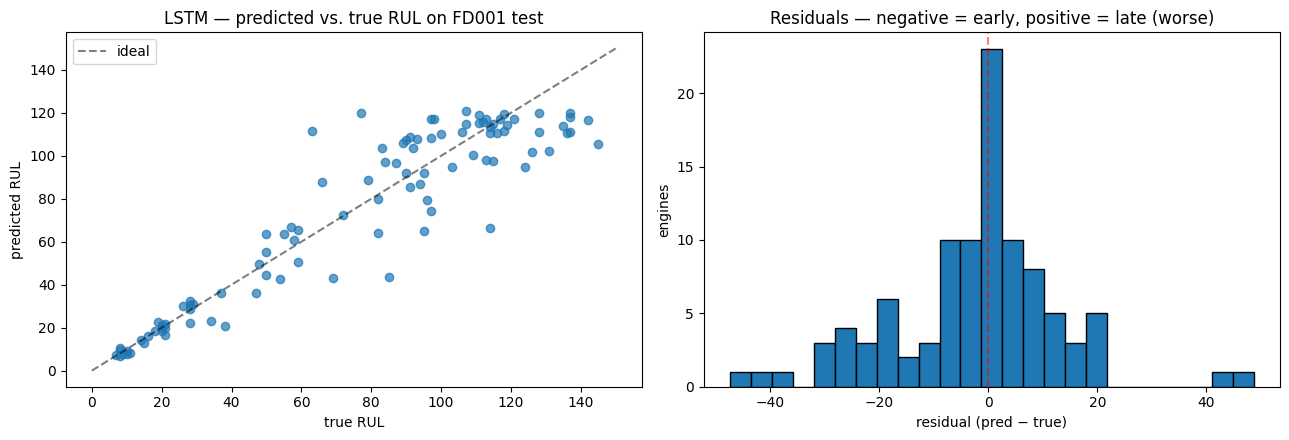

In [6]:
X_test_seq, _ = make_test_windows(test_df, sensor_cols, window=30, scaler=result.scaler)
result.model.eval()
with torch.no_grad():
    y_pred = result.model(torch.from_numpy(X_test_seq).to(device)).cpu().numpy()
y_pred = np.clip(y_pred, 0, None)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(y_test, y_pred, alpha=0.7)
lims = [0, max(y_test.max(), y_pred.max()) + 5]
axes[0].plot(lims, lims, 'k--', alpha=0.5, label='ideal')
axes[0].set_xlabel('true RUL'); axes[0].set_ylabel('predicted RUL')
axes[0].set_title('LSTM — predicted vs. true RUL on FD001 test')
axes[0].legend()

residuals = y_pred - y_test
axes[1].hist(residuals, bins=25, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('residual (pred − true)')
axes[1].set_ylabel('engines')
axes[1].set_title('Residuals — negative = early, positive = late (worse)')
fig.tight_layout()
print(f'Late predictions: {(residuals > 0).sum()}/{len(residuals)} engines')
print(f'Mean late residual : {residuals[residuals > 0].mean():.2f}')
print(f'Mean early residual: {residuals[residuals < 0].mean():.2f}')

## Honest take

If the LSTM's NASA score on FD001 is higher (worse) than LightGBM's, **that is the expected and correct outcome**. FD001 has a single operating condition and a single fault mode; the engineered rolling/FFT/CUSUM features in notebook 01 already encode all the temporal context that matters, and a tabular booster on those features dominates.

The story changes on **FD002** (six operating conditions) and **FD004** (six conditions × two fault modes), where the operating-condition switches force a model to disentangle regime from degradation — a sequence model with non-trivial parameters has a structural advantage there. Re-running this notebook against `load_cmapss('FD004')` is the natural next step.

## What's next: `04_survival_weibull_cox.ipynb`

We pivot from RUL regression to **survival analysis**. Weibull AFT and Cox PH on engine-level (not cycle-level) features, with concordance index (C-index) as the primary metric. This closes the LHH-job-description gap exactly: *modelos de supervivencia (Weibull, Cox)*.